<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session11: Logistic Regression From Scratch</font></h3>
<h3 align="center">Zahra Amini</h3>

# Libraries

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import matplotlib

import math

# Data

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], 
                    [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [3]:
X_train

array([[0.5, 1.5],
       [1. , 1. ],
       [1.5, 0.5],
       [3. , 0.5],
       [2. , 2. ],
       [1. , 2.5]])

In [4]:
y_train

array([0, 0, 0, 1, 1, 1])

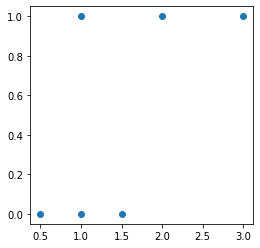

In [5]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))

plt.scatter(X_train[:, 0], y_train)

plt.show()

# Sigmoid

In [6]:
def sigmoid(z):
    
    g = 1/(1+np.exp(-z))
    
    return g

In [7]:
z_temp = np.arange(-10, 11)

y_z = sigmoid(z_temp)

np.set_printoptions(precision=3)
np.set_printoptions(formatter={'float_kind':'{:f}'.format})
print(np.c_[z_temp, y_z])

[[-10.000000 0.000045]
 [-9.000000 0.000123]
 [-8.000000 0.000335]
 [-7.000000 0.000911]
 [-6.000000 0.002473]
 [-5.000000 0.006693]
 [-4.000000 0.017986]
 [-3.000000 0.047426]
 [-2.000000 0.119203]
 [-1.000000 0.268941]
 [0.000000 0.500000]
 [1.000000 0.731059]
 [2.000000 0.880797]
 [3.000000 0.952574]
 [4.000000 0.982014]
 [5.000000 0.993307]
 [6.000000 0.997527]
 [7.000000 0.999089]
 [8.000000 0.999665]
 [9.000000 0.999877]
 [10.000000 0.999955]]


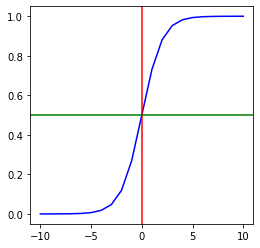

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(z_temp, y_z, c='b')

plt.axvline(x=0, color='r')

plt.axhline(0.5, color='g')
plt.show()

# Cost Function Logistic Regression

In [9]:
def cost_function(X, y, w, b):
    
    m = X.shape[0]
    cost = 0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb = sigmoid(z_i)
        
        cost += -y[i]* np.log(f_wb) - (1-y[i]) * np.log(1-f_wb)
        
    cost = cost/m
    
    return cost

# Gradient Descent

In [10]:
def gradient(X, y, w, b):
    
    m = X.shape[0]
    n = X.shape[1]
    
    dj_dw = np.zeros((n,))
    dj_db = 0
    
    for i in range(m):
        f_wb = sigmoid(np.dot(X[i], w) + b)
        
        loss = f_wb - y[i]
        
        for j in range(n):
            dj_dw[j] += loss* X[i, j]
        dj_db += loss
        
    dj_dw = dj_dw/m
    
    dj_db = dj_db/m
    
    return dj_dw, dj_db

In [11]:
w_init = np.array([0, 1])
b_init = 1
gradient(X_train, y_train, w_init, b_init)

(array([0.316298, 0.402742]), 0.39389162440250053)

# RUN Gradient Descent

In [12]:
def gradient_des(X, y, W, b, alpha, iters):
    J_history = []
    
    for i in range(iters):
        dj_dw, dj_db = gradient(X, y, W, b)
        
        W = W - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = cost_function(X, y, W, b)
        J_history.append(cost)
        
        print("iter:", i, "Cost: ", J_history[i])
    return W, b 

In [13]:
W=np.zeros_like(X_train[0])
b=1
alpha=0.1
iters=10000
W, b = gradient_des(X_train, y_train, W, b, alpha, iters)

iter: 0 Cost:  0.8053167896947814
iter: 1 Cost:  0.7985567112569157
iter: 2 Cost:  0.7927659089619055
iter: 3 Cost:  0.787761182563692
iter: 4 Cost:  0.7833893932745668
iter: 5 Cost:  0.779524297269314
iter: 6 Cost:  0.7760630200842505
iter: 7 Cost:  0.772922534047214
iter: 8 Cost:  0.7700363629797241
iter: 9 Cost:  0.7673516337836345
iter: 10 Cost:  0.7648265216281732
iter: 11 Cost:  0.7624280887125714
iter: 12 Cost:  0.7601304894383132
iter: 13 Cost:  0.757913501317533
iter: 14 Cost:  0.7557613362949204
iter: 15 Cost:  0.7536616878532962
iter: 16 Cost:  0.7516049728790274
iter: 17 Cost:  0.7495837321979972
iter: 18 Cost:  0.7475921589813249
iter: 19 Cost:  0.7456257293055276
iter: 20 Cost:  0.743680913750009
iter: 21 Cost:  0.7417549529107897
iter: 22 Cost:  0.7398456830881042
iter: 23 Cost:  0.7379514012057081
iter: 24 Cost:  0.7360707603058412
iter: 25 Cost:  0.7342026888085581
iter: 26 Cost:  0.7323463281992
iter: 27 Cost:  0.7305009849785472
iter: 28 Cost:  0.7286660936339793
ite

iter: 281 Cost:  0.4247729603805392
iter: 282 Cost:  0.4239932660592481
iter: 283 Cost:  0.42321590817735616
iter: 284 Cost:  0.4224408781299198
iter: 285 Cost:  0.4216681673444435
iter: 286 Cost:  0.4208977672807895
iter: 287 Cost:  0.4201296694310892
iter: 288 Cost:  0.41936386531965314
iter: 289 Cost:  0.4186003465028805
iter: 290 Cost:  0.4178391045691705
iter: 291 Cost:  0.417080131138831
iter: 292 Cost:  0.41632341786398924
iter: 293 Cost:  0.41556895642850095
iter: 294 Cost:  0.4148167385478601
iter: 295 Cost:  0.41406675596910864
iter: 296 Cost:  0.41331900047074516
iter: 297 Cost:  0.4125734638626348
iter: 298 Cost:  0.4118301379859178
iter: 299 Cost:  0.4110890147129185
iter: 300 Cost:  0.4103500859470544
iter: 301 Cost:  0.4096133436227451
iter: 302 Cost:  0.40887877970532
iter: 303 Cost:  0.408146386190928
iter: 304 Cost:  0.4074161551064448
iter: 305 Cost:  0.40668807850938177
iter: 306 Cost:  0.40596214848779416
iter: 307 Cost:  0.40523835716018936
iter: 308 Cost:  0.4045

iter: 560 Cost:  0.27382023565611685
iter: 561 Cost:  0.27345268273770346
iter: 562 Cost:  0.27308600769012875
iter: 563 Cost:  0.2727202076684638
iter: 564 Cost:  0.27235527983886204
iter: 565 Cost:  0.2719912213785118
iter: 566 Cost:  0.2716280294755889
iter: 567 Cost:  0.2712657013292095
iter: 568 Cost:  0.27090423414938297
iter: 569 Cost:  0.2705436251569654
iter: 570 Cost:  0.27018387158361296
iter: 571 Cost:  0.26982497067173533
iter: 572 Cost:  0.26946691967444963
iter: 573 Cost:  0.2691097158555347
iter: 574 Cost:  0.268753356489385
iter: 575 Cost:  0.268397838860965
iter: 576 Cost:  0.2680431602657644
iter: 577 Cost:  0.26768931800975204
iter: 578 Cost:  0.26733630940933173
iter: 579 Cost:  0.2669841317912968
iter: 580 Cost:  0.2666327824927861
iter: 581 Cost:  0.26628225886123913
iter: 582 Cost:  0.265932558254352
iter: 583 Cost:  0.2655836780400336
iter: 584 Cost:  0.26523561559636116
iter: 585 Cost:  0.26488836831153745
iter: 586 Cost:  0.26454193358384664
iter: 587 Cost:  

iter: 854 Cost:  0.19433202094169666
iter: 855 Cost:  0.19413501070118358
iter: 856 Cost:  0.19393837025675065
iter: 857 Cost:  0.193742098629754
iter: 858 Cost:  0.19354619484480948
iter: 859 Cost:  0.19335065792977993
iter: 860 Cost:  0.19315548691576245
iter: 861 Cost:  0.19296068083707565
iter: 862 Cost:  0.1927662387312474
iter: 863 Cost:  0.19257215963900154
iter: 864 Cost:  0.19237844260424616
iter: 865 Cost:  0.19218508667406087
iter: 866 Cost:  0.19199209089868385
iter: 867 Cost:  0.19179945433150047
iter: 868 Cost:  0.1916071760290302
iter: 869 Cost:  0.19141525505091503
iter: 870 Cost:  0.1912236904599064
iter: 871 Cost:  0.19103248132185427
iter: 872 Cost:  0.19084162670569393
iter: 873 Cost:  0.19065112568343454
iter: 874 Cost:  0.19046097733014714
iter: 875 Cost:  0.19027118072395263
iter: 876 Cost:  0.19008173494600974
iter: 877 Cost:  0.18989263908050366
iter: 878 Cost:  0.18970389221463382
iter: 879 Cost:  0.18951549343860266
iter: 880 Cost:  0.18932744184560316
iter: 

iter: 1127 Cost:  0.1516038468726302
iter: 1128 Cost:  0.1514800576517474
iter: 1129 Cost:  0.1513564592901349
iter: 1130 Cost:  0.15123305136569587
iter: 1131 Cost:  0.15110983345752968
iter: 1132 Cost:  0.15098680514592816
iter: 1133 Cost:  0.15086396601237118
iter: 1134 Cost:  0.15074131563952295
iter: 1135 Cost:  0.1506188536112275
iter: 1136 Cost:  0.15049657951250542
iter: 1137 Cost:  0.15037449292954905
iter: 1138 Cost:  0.15025259344971906
iter: 1139 Cost:  0.15013088066154018
iter: 1140 Cost:  0.15000935415469727
iter: 1141 Cost:  0.1498880135200317
iter: 1142 Cost:  0.14976685834953699
iter: 1143 Cost:  0.1496458882363552
iter: 1144 Cost:  0.1495251027747729
iter: 1145 Cost:  0.14940450156021728
iter: 1146 Cost:  0.1492840841892524
iter: 1147 Cost:  0.14916385025957543
iter: 1148 Cost:  0.14904379937001241
iter: 1149 Cost:  0.14892393112051486
iter: 1150 Cost:  0.14880424511215565
iter: 1151 Cost:  0.14868474094712567
iter: 1152 Cost:  0.14856541822872957
iter: 1153 Cost:  0.

...

iter: 8434 Cost:  0.020484147809551823
iter: 8435 Cost:  0.02048168498140718
iter: 8436 Cost:  0.020479222742655616
iter: 8437 Cost:  0.020476761093086333
iter: 8438 Cost:  0.02047430003248863
iter: 8439 Cost:  0.02047183956065206
iter: 8440 Cost:  0.020469379677366076
iter: 8441 Cost:  0.020466920382420418
iter: 8442 Cost:  0.020464461675604843
iter: 8443 Cost:  0.020462003556709237
iter: 8444 Cost:  0.020459546025523443
iter: 8445 Cost:  0.020457089081837725
iter: 8446 Cost:  0.02045463272544201
iter: 8447 Cost:  0.02045217695612677
iter: 8448 Cost:  0.02044972177368229
iter: 8449 Cost:  0.02044726717789899
iter: 8450 Cost:  0.020444813168567468
iter: 8451 Cost:  0.020442359745478433
iter: 8452 Cost:  0.020439906908422494
iter: 8453 Cost:  0.020437454657190705
iter: 8454 Cost:  0.02043500299157391
iter: 8455 Cost:  0.02043255191136314
iter: 8456 Cost:  0.020430101416349575
iter: 8457 Cost:  0.020427651506324505
iter: 8458 Cost:  0.020425202181079304
iter: 8459 Cost:  0.02042275344040

iter: 8699 Cost:  0.019851488587859577
iter: 8700 Cost:  0.01984917487287972
iter: 8701 Cost:  0.019846861694776678
iter: 8702 Cost:  0.019844549053364163
iter: 8703 Cost:  0.019842236948456184
iter: 8704 Cost:  0.019839925379866705
iter: 8705 Cost:  0.019837614347409865
iter: 8706 Cost:  0.019835303850899856
iter: 8707 Cost:  0.019832993890150877
iter: 8708 Cost:  0.0198306844649774
iter: 8709 Cost:  0.01982837557519379
iter: 8710 Cost:  0.019826067220614658
iter: 8711 Cost:  0.019823759401054575
iter: 8712 Cost:  0.019821452116328162
iter: 8713 Cost:  0.01981914536625035
iter: 8714 Cost:  0.01981683915063595
iter: 8715 Cost:  0.01981453346929985
iter: 8716 Cost:  0.01981222832205724
iter: 8717 Cost:  0.01980992370872317
iter: 8718 Cost:  0.01980761962911279
iter: 8719 Cost:  0.019805316083041487
iter: 8720 Cost:  0.019803013070324622
iter: 8721 Cost:  0.019800710590777693
iter: 8722 Cost:  0.01979840864421614
iter: 8723 Cost:  0.01979610723045571
iter: 8724 Cost:  0.01979380634931207

iter: 9019 Cost:  0.019137530340193585
iter: 9020 Cost:  0.019135379368366293
iter: 9021 Cost:  0.019133228877972194
iter: 9022 Cost:  0.019131078868850515
iter: 9023 Cost:  0.01912892934084013
iter: 9024 Cost:  0.019126780293780205
iter: 9025 Cost:  0.019124631727509788
iter: 9026 Cost:  0.01912248364186821
iter: 9027 Cost:  0.019120336036694874
iter: 9028 Cost:  0.019118188911828992
iter: 9029 Cost:  0.019116042267110077
iter: 9030 Cost:  0.019113896102377702
iter: 9031 Cost:  0.01911175041747143
iter: 9032 Cost:  0.0191096052122309
iter: 9033 Cost:  0.019107460486495937
iter: 9034 Cost:  0.019105316240106276
iter: 9035 Cost:  0.019103172472901896
iter: 9036 Cost:  0.01910102918472259
iter: 9037 Cost:  0.019098886375408533
iter: 9038 Cost:  0.019096744044799722
iter: 9039 Cost:  0.0190946021927364
iter: 9040 Cost:  0.0190924608190588
iter: 9041 Cost:  0.01909031992360713
iter: 9042 Cost:  0.019088179506221877
iter: 9043 Cost:  0.019086039566743457
iter: 9044 Cost:  0.0190839001050123

iter: 9378 Cost:  0.01839508421307522
iter: 9379 Cost:  0.01839309624871471
iter: 9380 Cost:  0.0183911087122875
iter: 9381 Cost:  0.018389121603655984
iter: 9382 Cost:  0.018387134922682447
iter: 9383 Cost:  0.018385148669229395
iter: 9384 Cost:  0.018383162843159263
iter: 9385 Cost:  0.018381177444334536
iter: 9386 Cost:  0.018379192472617857
iter: 9387 Cost:  0.018377207927871897
iter: 9388 Cost:  0.018375223809959314
iter: 9389 Cost:  0.018373240118742903
iter: 9390 Cost:  0.018371256854085503
iter: 9391 Cost:  0.018369274015850038
iter: 9392 Cost:  0.018367291603899386
iter: 9393 Cost:  0.018365309618096595
iter: 9394 Cost:  0.01836332805830468
iter: 9395 Cost:  0.018361346924386828
iter: 9396 Cost:  0.018359366216206194
iter: 9397 Cost:  0.018357385933625955
iter: 9398 Cost:  0.018355406076509515
iter: 9399 Cost:  0.01835342664472018
iter: 9400 Cost:  0.018351447638121302
iter: 9401 Cost:  0.018349469056576462
iter: 9402 Cost:  0.018347490899949182
iter: 9403 Cost:  0.01834551316

iter: 9707 Cost:  0.01776335095969399
iter: 9708 Cost:  0.01776149668766869
iter: 9709 Cost:  0.017759642801276305
iter: 9710 Cost:  0.017757789300396953
iter: 9711 Cost:  0.017755936184910757
iter: 9712 Cost:  0.01775408345469795
iter: 9713 Cost:  0.017752231109638757
iter: 9714 Cost:  0.01775037914961345
iter: 9715 Cost:  0.01774852757450239
iter: 9716 Cost:  0.017746676384185964
iter: 9717 Cost:  0.01774482557854468
iter: 9718 Cost:  0.01774297515745897
iter: 9719 Cost:  0.0177411251208093
iter: 9720 Cost:  0.017739275468476423
iter: 9721 Cost:  0.017737426200340856
iter: 9722 Cost:  0.017735577316283325
iter: 9723 Cost:  0.017733728816184617
iter: 9724 Cost:  0.017731880699925474
iter: 9725 Cost:  0.017730032967386688
iter: 9726 Cost:  0.017728185618449292
iter: 9727 Cost:  0.017726338652993983
iter: 9728 Cost:  0.017724492070901997
iter: 9729 Cost:  0.017722645872054247
iter: 9730 Cost:  0.017720800056331813
iter: 9731 Cost:  0.01771895462361586
iter: 9732 Cost:  0.017717109573787

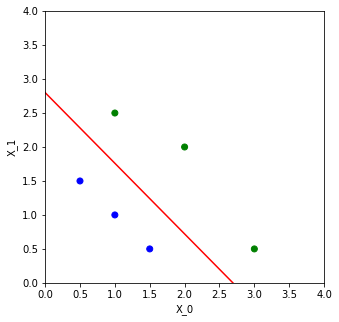

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.set_xlabel('X_0')
ax.set_ylabel('X_1')

ax.axis([0,4,0,4])

label = y_train

colors = ['blue', 'green']

plt.scatter(X_train[:, 0], X_train[:, 1], c=label, 
            cmap=matplotlib.colors.ListedColormap(colors))

x0 = -b/W[0]

x1=-b/W[1]

ax.plot([0, x0], [x1, 0], c='r')